In [1]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/operator_experiment'

errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])
entries_df = pd.read_csv(os.path.join(dir, 'entries.csv')).drop(columns=['Unnamed: 0'])
rps_df = pd.read_csv(os.path.join(dir, 'rps.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

config

errors_df

,1,10,50,88
0,20.046553,3.902449,7.030855,4.890957
1,19.338513,4.076676,6.809560,5.129850
2,19.485308,3.985368,6.861776,5.103780
3,19.336793,3.907199,7.051996,5.120276
4,19.811838,4.045124,6.946328,4.968332
5,19.704074,4.068584,7.014000,5.056718
6,19.797262,4.031161,6.862467,4.855207
7,19.300823,3.940261,6.935311,5.117606
8,19.867971,3.952452,7.031143,5.038587
9,19.408052,4.006624,7.025602,4.895310


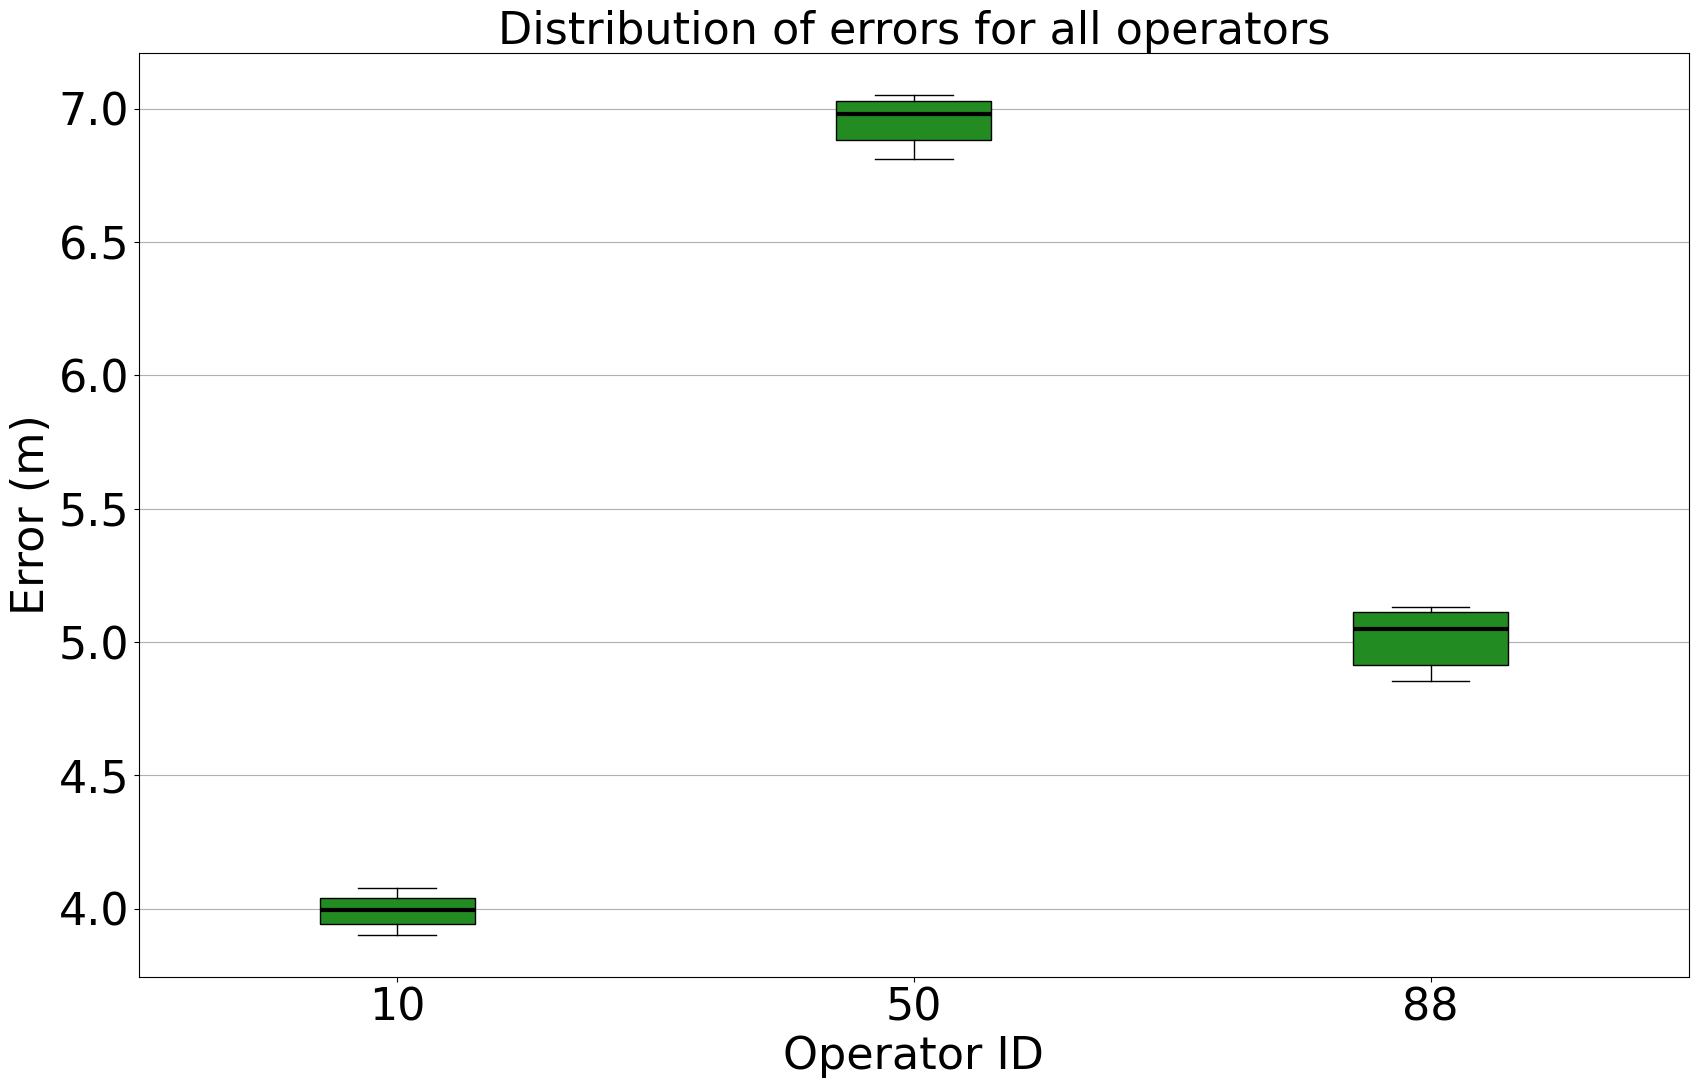

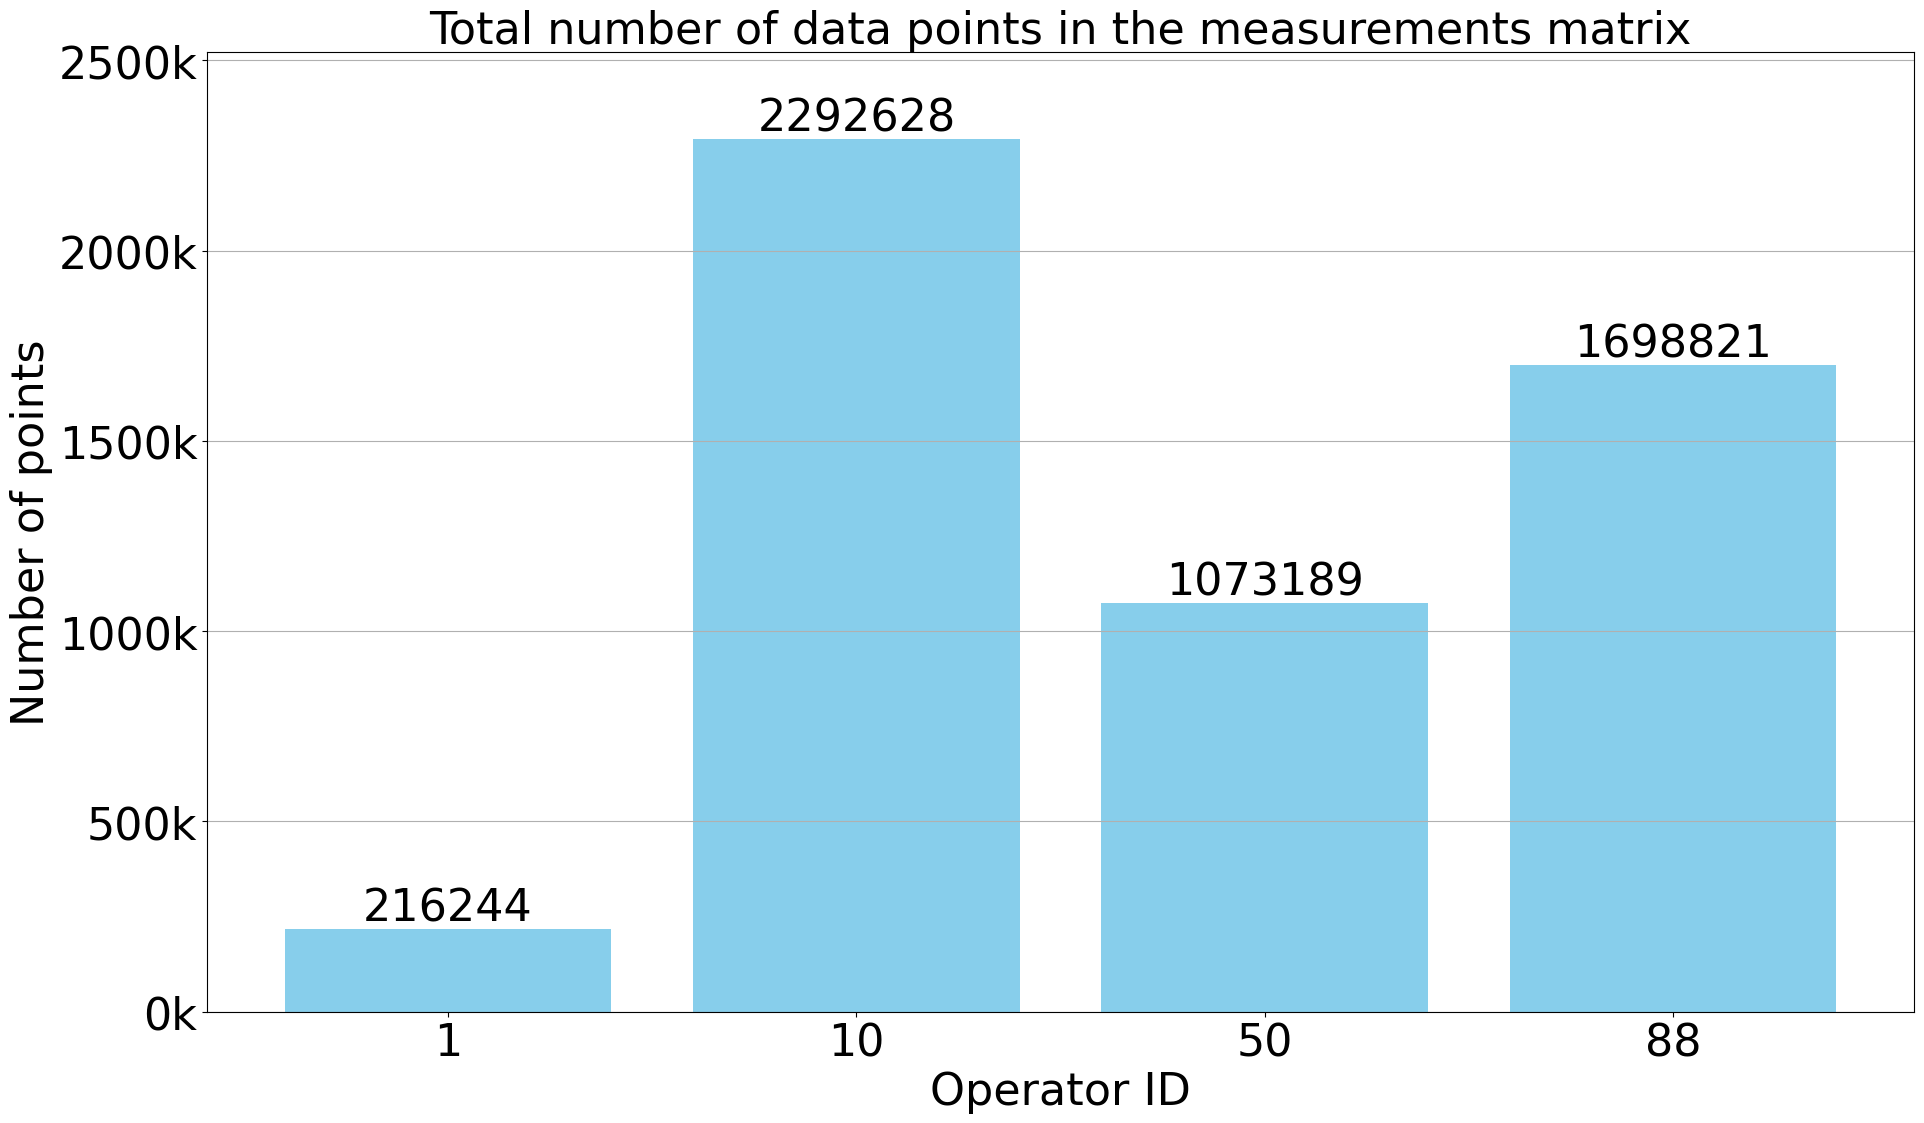

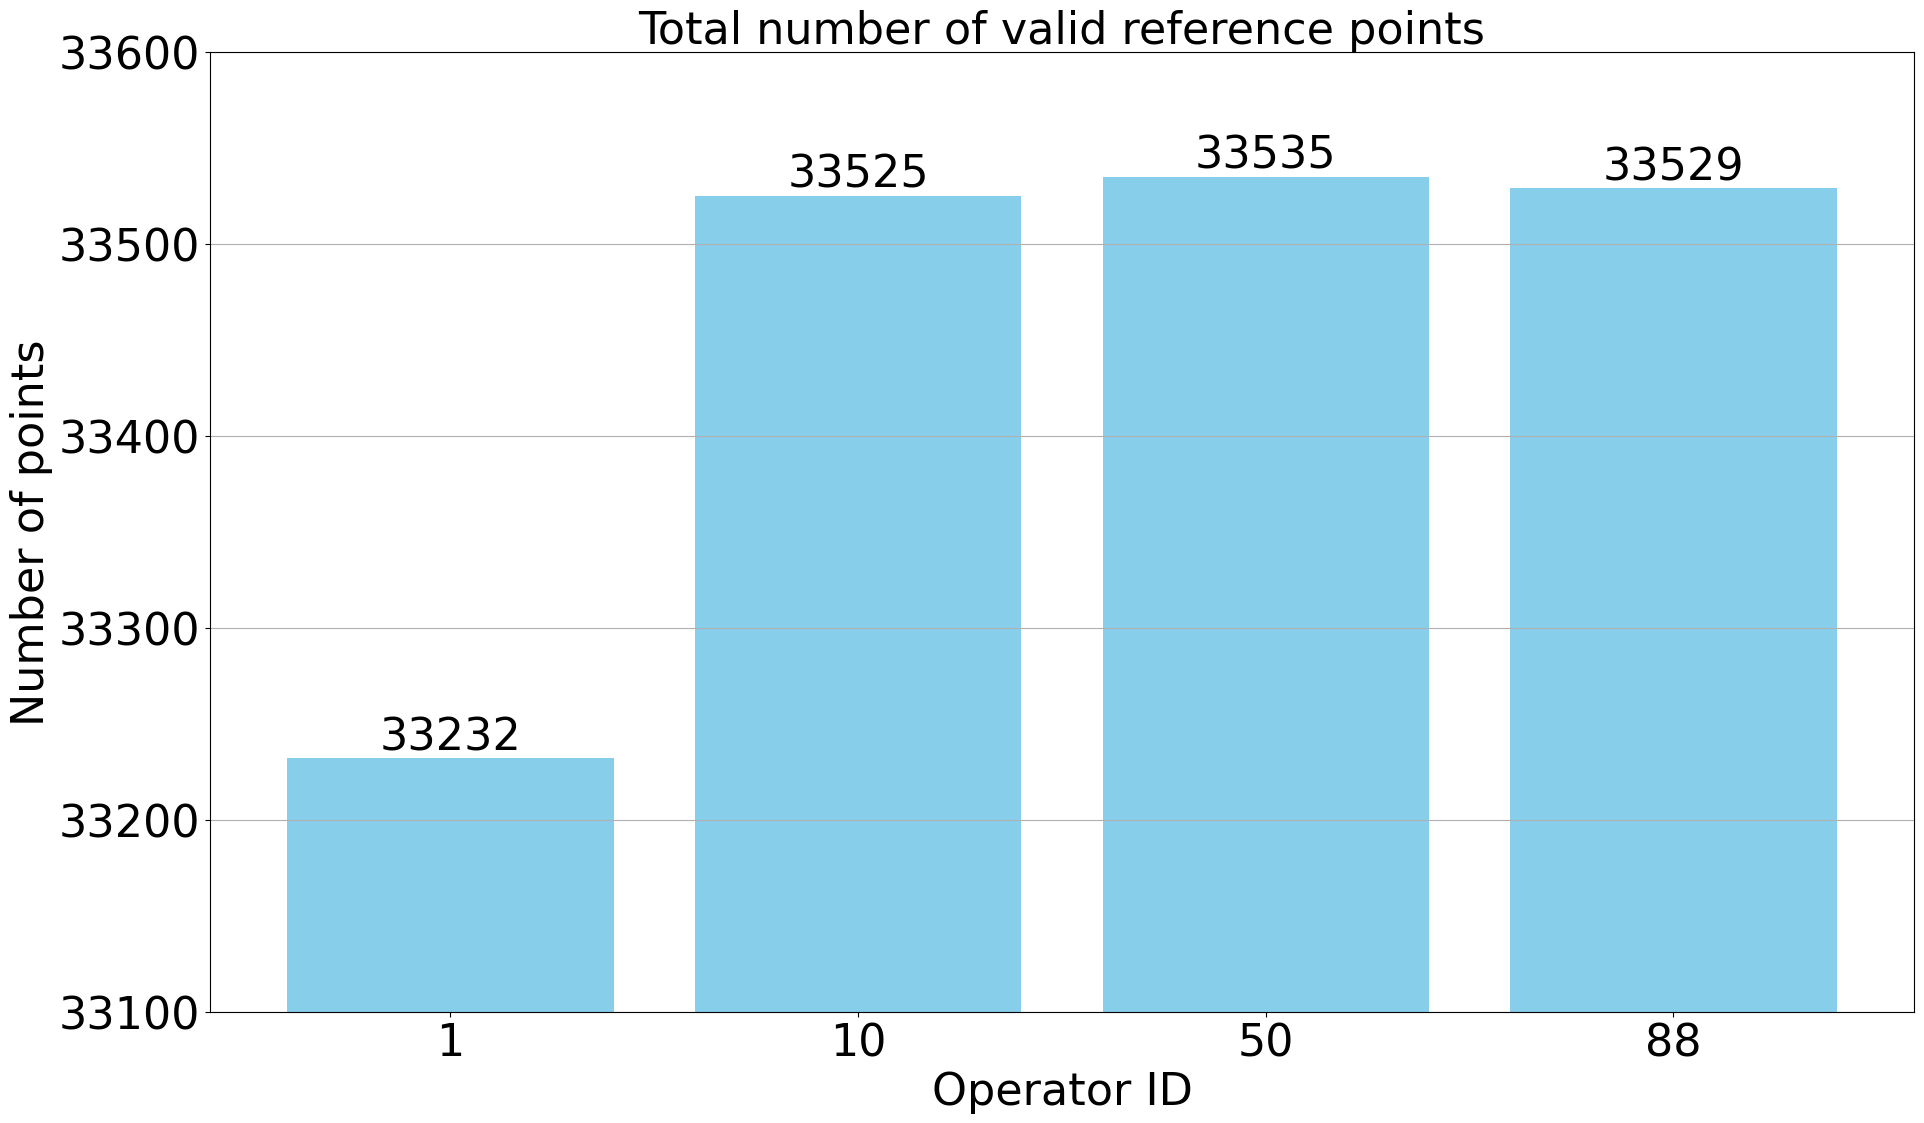

,1,10,50,88
0,33232,33525,33535,33529


In [7]:
from scripts.plotting import *

make_boxplot(
    df=errors_df[['10', '50', '88']],
    x_label='Operator ID',
    y_label='Error (m)',
    title='Distribution of errors for all operators',
)

make_barplot(
    df=entries_df,
    x_label='Operator ID',
    y_label='Number of points',
    title='Total number of data points in the measurements matrix',
    annotate=True,
    y_formatter=lambda x, pos: f"{x / 1000:.0f}k"

)

make_barplot(
    df=rps_df,
    x_label='Operator ID',
    y_label='Number of points',
    title='Total number of valid reference points',
    y_limit=(33100, 33600),
    annotate=True,

)

rps_df

        error    entries
1   19.609719   216244.0
10   3.991590  2292628.0
50   6.956904  1073189.0
88   5.017662  1698821.0


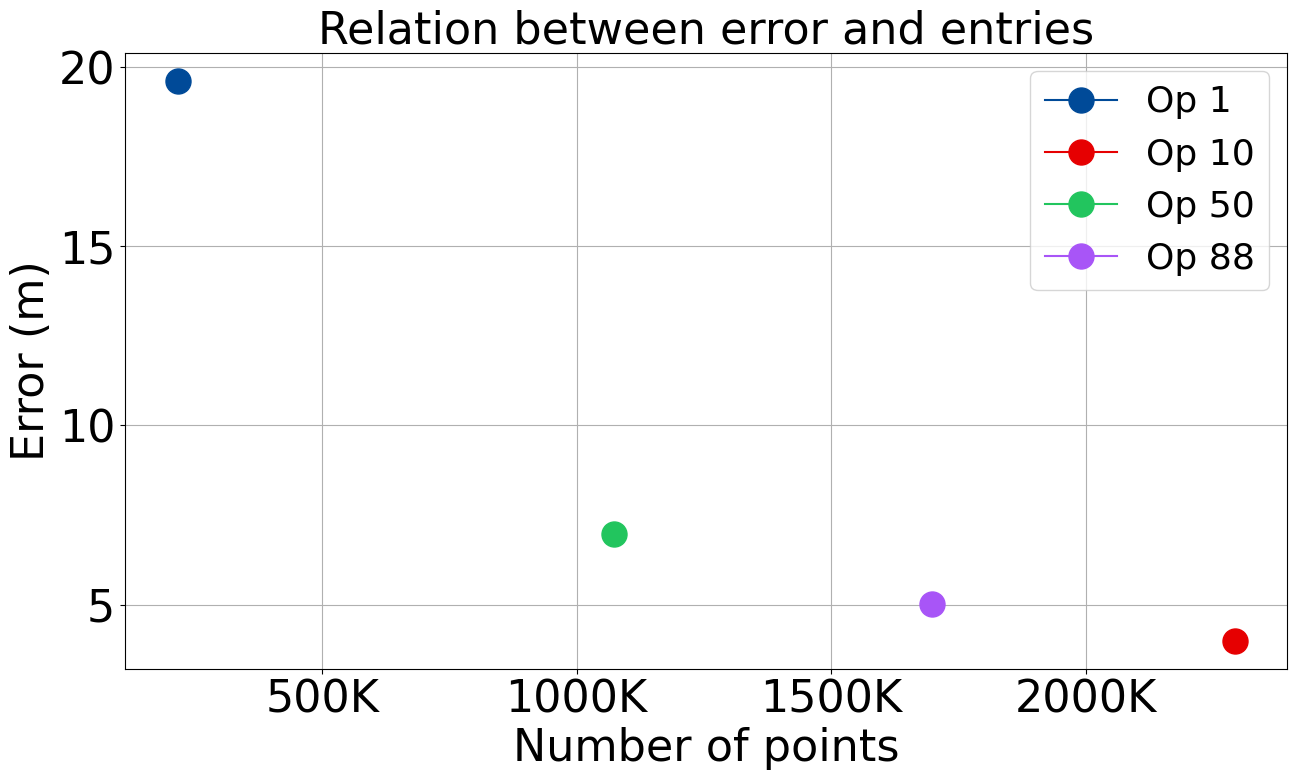

In [47]:


ratio_df = pd.DataFrame({
    'error': errors_df.mean(),
    'entries': entries_df.mean(),
})

from scripts.utils import get_config

color_map = get_config("color_map.json", "operatorId")

print(ratio_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i, row in ratio_df.iterrows():
    plt.plot(row['entries'], row['error'], label=f"Op {i}", marker='o', markersize=18, c=color_map[i])

plt.grid(True)
plt.legend()
plt.ylabel('Error (m)')
plt.title('Relation between error and entries')
plt.xlabel('Number of points')


def thousands_formatter(x, pos):
    return f"{x / 1000:.0f}k"


plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{(x / 1000):.0f}K"))

plt.show()